# Difference-in-Differences (DiD) Analysis

## Overview

This notebook estimates the average treatment effect of hospital mergers using a Difference-in-Differences (DiD) framework.

The analysis builds on the same hospital-year panel and treatment-timing design used in the parallel-trends check, but now focuses on **outcome levels after merger**.

The **primary outcome** here is:

- `cost_per_discharge`: operating cost per inpatient discharge for a hospital-year

For scale stability and skew reduction, we work with the log-transformed outcome:

- `log_cost_per_discharge = log(1 + cost_per_discharge)`

Standard errors are clustered at the hospital (`ccn`) level.

## Objectives

- Construct a clean analytic sample for DiD estimation using the merger timing fields
- Estimate the average treatment effect of mergers on **log cost per discharge** using a structure with calendar-year fixed effects
- Provide benchmark results for other outcomes (e.g., bankruptcy) using the same DiD design
- Offer plain-language interpretations of the key DiD coefficients

## Dataset Description

We use the hospital analysis panel at the hospital-year level from `01_data/hospital_analysis.csv`.
Key fields include (among others):

- `fiscal_year`: calendar year of the hospital fiscal period
- `treated`: 1 if the hospital ever experiences a merger, 0 otherwise
- `merger_year` / `years_to_merger`: timing of the hospital's first merger
- `post_merger`: 1 for treated hospitals in years on/after their first merger year, 0 otherwise
- `cost_per_discharge`: operating cost per discharge (main outcome in this notebook)

## Key Considerations

- Interpretation is in **log points** and approximately **percent changes** in cost per discharge (via `exp(beta) - 1`)
- Calendar-year fixed effects absorb aggregate shocks (e.g., macro trends, policy changes common to all hospitals)
- `treated` is effectively time-invariant at the hospital level, so hospital fixed effects would be collinear with it; instead we use a specification with `treated` and year fixed effects
- The identifying assumption is the same as in the parallel-trends notebook: absent mergers, treated and never-treated hospitals would have had parallel trends in the outcome

## Outcome

By the end of this notebook you should have:

- A descriptive view of **average log cost per discharge** over time for treated vs. never-treated hospitals
- A baseline DiD estimate of the effect of mergers on log cost per discharge
- A complementary DiD estimate for bankruptcy risk
- Written interpretations to help translate the regression output into economic magnitudes and directions.


In [8]:
# Imports
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

In [9]:
# Load hospital analysis dataset
cwd = Path.cwd()
project_root = cwd if (cwd / "01_data").exists() else cwd.parent

data_path = project_root / "01_data" / "hospital_analysis.csv"
hospital_analysis = pd.read_csv(data_path)

df = hospital_analysis.copy()

# Standardize key fields used by DiD
df["fiscal_year"] = pd.to_numeric(df["fiscal_year"], errors="coerce")
df["treated"] = pd.to_numeric(df["treated"], errors="coerce")
df["post_merger"] = pd.to_numeric(df["post_merger"], errors="coerce")

# Clean outcome so log(1 + x) is well-defined
df["total_operating_costs"] = pd.to_numeric(df["total_operating_costs"], errors="coerce")
df = df[df["total_operating_costs"].notna()].copy()
df = df[df["total_operating_costs"] >= 0].copy()
df["log_total_operating_costs"] = np.log1p(df["total_operating_costs"])

# Main DiD outcome: cost per discharge (and its log).
df["cost_per_discharge"] = pd.to_numeric(df.get("cost_per_discharge"), errors="coerce")
df = df[df["cost_per_discharge"].notna()].copy()
df = df[df["cost_per_discharge"] >= 0].copy()
df["log_cost_per_discharge"] = np.log1p(df["cost_per_discharge"])

# Bankruptcy is used as an outcome via a linear probability model (OLS)
if "bankruptcy" in df.columns:
    df["bankruptcy"] = pd.to_numeric(df["bankruptcy"], errors="coerce")

print("Loaded DiD frame shape:", df.shape)
print("Treated hospitals:", df.loc[df["treated"] == 1, "ccn"].nunique())
print("Control hospitals:", df.loc[df["treated"] == 0, "ccn"].nunique())

Loaded DiD frame shape: (53354, 32)
Treated hospitals: 1242
Control hospitals: 5219


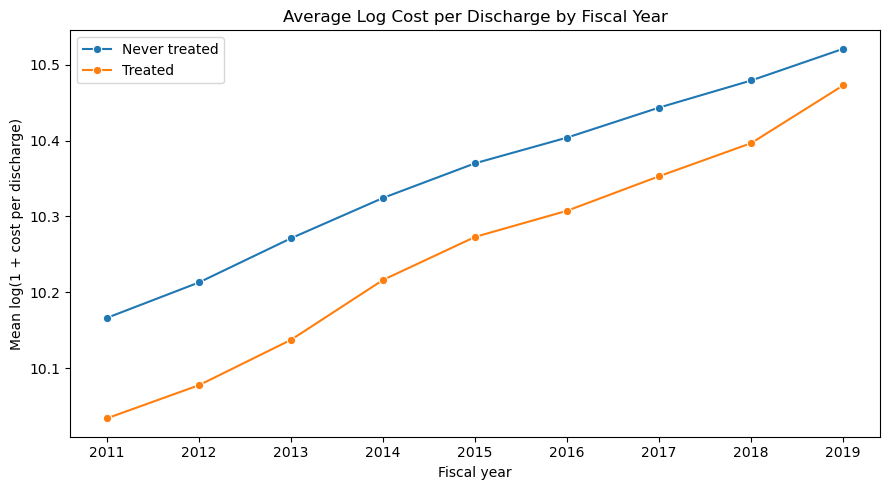

In [10]:
# Descriptive plot: average log cost per discharge by fiscal year

plot_df = (
    df.groupby(["fiscal_year", "treated"], as_index=False)["log_cost_per_discharge"]
    .mean()
)

plot_df["group"] = plot_df["treated"].map({0: "Never treated", 1: "Treated"})

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=plot_df,
    x="fiscal_year",
    y="log_cost_per_discharge",
    hue="group",
    marker="o",
)

plt.title("Average Log Cost per Discharge by Fiscal Year")
plt.xlabel("Fiscal year")
plt.ylabel("Mean log(1 + cost per discharge)")
plt.xticks(sorted(df["fiscal_year"].dropna().unique().tolist()))
plt.legend()
plt.tight_layout()
# Save and show in the notebook UI.
out_dir = project_root / "05_outputs" / "figures"
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / "did_avg_log_cost_per_discharge_by_fiscal_year.png", dpi=200)
plt.show()
plt.close()


In [11]:
# Main DiD regression for log cost per discharge
# Specification:
#   log_cost_per_discharge ~ treated + treated:post_merger + C(fiscal_year)
# The coefficient on (treated:post_merger) is the DiD estimate.

reg_df = df.dropna(
    subset=["fiscal_year", "treated", "post_merger", "log_cost_per_discharge"]
).copy()

# Cast to numpy int after NA-drop (patsy prefers non-nullable dtypes).
for _col in ["fiscal_year", "treated", "post_merger"]:
    reg_df[_col] = reg_df[_col].astype(int)

cost_model = smf.ols(
    "log_cost_per_discharge ~ treated + treated:post_merger + C(fiscal_year)",
    data=reg_df,
).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_df["ccn"]},
)

print("DiD (Log Cost per Discharge) - clustered by ccn")
print("=" * 70)
print(cost_model.summary())

att_log_points = float(cost_model.params.get("treated:post_merger", np.nan))
if np.isfinite(att_log_points):
    # Approx percent effect in levels: exp(beta) - 1
    att_pct = 100.0 * (np.exp(att_log_points) - 1.0)
    print(f"\nDiD ATT (log points): {att_log_points:.6f}")
    print(f"DiD ATT (approx % change in cost per discharge): {att_pct:.2f}%")


DiD (Log Cost per Discharge) - clustered by ccn
                              OLS Regression Results                              
Dep. Variable:     log_cost_per_discharge   R-squared:                       0.022
Model:                                OLS   Adj. R-squared:                  0.022
Method:                     Least Squares   F-statistic:                     156.6
Date:                    Thu, 16 Apr 2026   Prob (F-statistic):          2.66e-295
Time:                            14:39:29   Log-Likelihood:                -66199.
No. Observations:                   53354   AIC:                         1.324e+05
Df Residuals:                       53343   BIC:                         1.325e+05
Df Model:                              10                                         
Covariance Type:                  cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------

## Interpretation: Effect on Cost per Discharge

After running the regression above, focus on the coefficient on `treated:post_merger`:

- **Sign**: If the coefficient is negative, mergers are associated with *lower* log cost per discharge for treated hospitals after the merger, relative to never-treated controls. If positive, mergers are associated with *higher* cost per discharge.
- **Magnitude**: The printed `approx % change in cost per discharge` (computed as `exp(beta) - 1`) gives a percent interpretation. For example, a coefficient of about -0.20 would correspond to roughly an 18–20% reduction in cost per discharge.
- **Statistical significance**: Use the `P>|z|` value for `treated:post_merger` to judge whether the effect is statistically distinguishable from zero (e.g., at the 5% level).

Together with the parallel-trends diagnostics, this DiD estimate summarizes how hospital mergers are associated with changes in average cost per discharge for treated hospitals relative to comparable never-treated hospitals.


In [12]:
# DiD regression for bankruptcy (linear probability model)
if "bankruptcy" in reg_df.columns:
    bank_df = reg_df.dropna(subset=["bankruptcy"]).copy()
    
    for _col in ["fiscal_year", "treated", "post_merger"]:
        bank_df[_col] = bank_df[_col].astype(int)

    bank_model = smf.ols(
        "bankruptcy ~ treated + treated:post_merger + C(fiscal_year)",
        data=bank_df,
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": bank_df["ccn"]},
    )

    print("\nDiD (Bankruptcy) - clustered by ccn")
    print("=" * 70)
    print(bank_model.summary())

    att_bank = float(bank_model.params.get("treated:post_merger", np.nan))
    if np.isfinite(att_bank):
        print(f"\nDiD ATT (probability points): {att_bank:.6f}")
else:
    print("Column `bankruptcy` not found; skipping bankruptcy regression.")


DiD (Bankruptcy) - clustered by ccn
                            OLS Regression Results                            
Dep. Variable:             bankruptcy   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.647
Date:                Thu, 16 Apr 2026   Prob (F-statistic):             0.0871
Time:                        14:39:30   Log-Likelihood:             1.3758e+05
No. Observations:               53354   AIC:                        -2.751e+05
Df Residuals:                   53343   BIC:                        -2.750e+05
Df Model:                          10                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------

## Interpretation: Effect on Bankruptcy Risk

The bankruptcy regression uses the same DiD structure but with a binary outcome interpreted as a linear probability model.

- The coefficient on `treated:post_merger` is interpreted in **probability points** (e.g., 0.01 ≈ 1 percentage point).
- A positive and significant coefficient suggests that mergers are associated with a higher probability of bankruptcy for treated hospitals after the merger, relative to never-treated controls.
- A negative and significant coefficient would suggest a lower post-merger bankruptcy risk.

As with cost per discharge, this interpretation relies on the parallel-trends assumption established in the separate parallel-trend analysis notebook.


In [13]:
# Robustness check: interaction-only specification
rob_cost = smf.ols(
    "log_total_operating_costs ~ treated:post_merger + C(fiscal_year)",
    data=reg_df,
).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_df["ccn"]},
)

print("\nRobustness: interaction-only (operating costs)")
print("=" * 70)
print(rob_cost.summary())


Robustness: interaction-only (operating costs)
                                OLS Regression Results                               
Dep. Variable:     log_total_operating_costs   R-squared:                       0.011
Model:                                   OLS   Adj. R-squared:                  0.011
Method:                        Least Squares   F-statistic:                     59.95
Date:                       Thu, 16 Apr 2026   Prob (F-statistic):          6.34e-106
Time:                               14:39:30   Log-Likelihood:                -96872.
No. Observations:                      53354   AIC:                         1.938e+05
Df Residuals:                          53344   BIC:                         1.939e+05
Df Model:                                  9                                         
Covariance Type:                     cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
-

## Robustness Interpretation

The interaction-only specification (`log_cost_per_discharge ~ treated:post_merger + C(fiscal_year)`) drops the separate `treated` main effect and focuses entirely on the treated-by-post interaction.

- If the sign and magnitude of `treated:post_merger` in this robustness model are similar to the baseline, it reinforces the stability of the estimated merger effect.
- Large changes in the coefficient or its significance between specifications may indicate sensitivity to functional form or collinearity.

This check is meant to complement the baseline DiD, not replace it.


## Notes

1. The key DiD parameter is the coefficient on `treated:post_merger`.
2. Standard errors are clustered at the hospital (`ccn`) level.
3. Bankruptcy uses a linear probability model (OLS).